     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

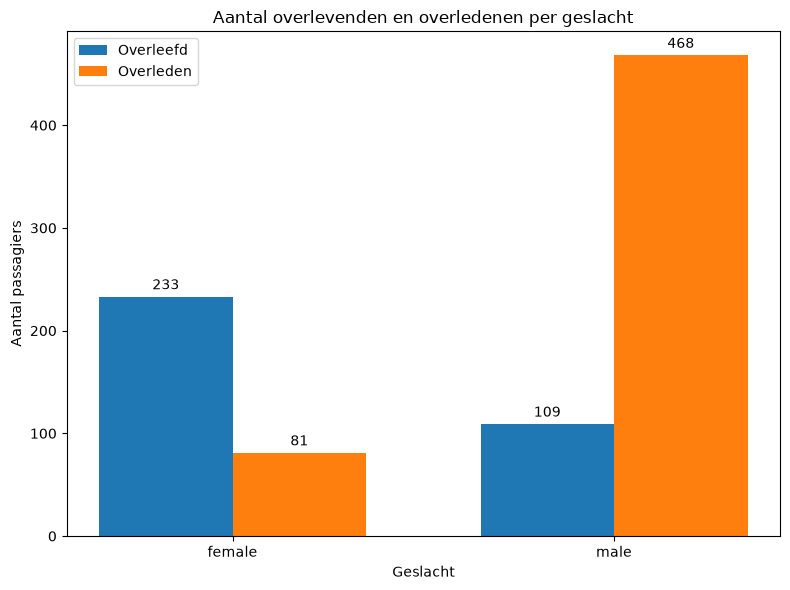

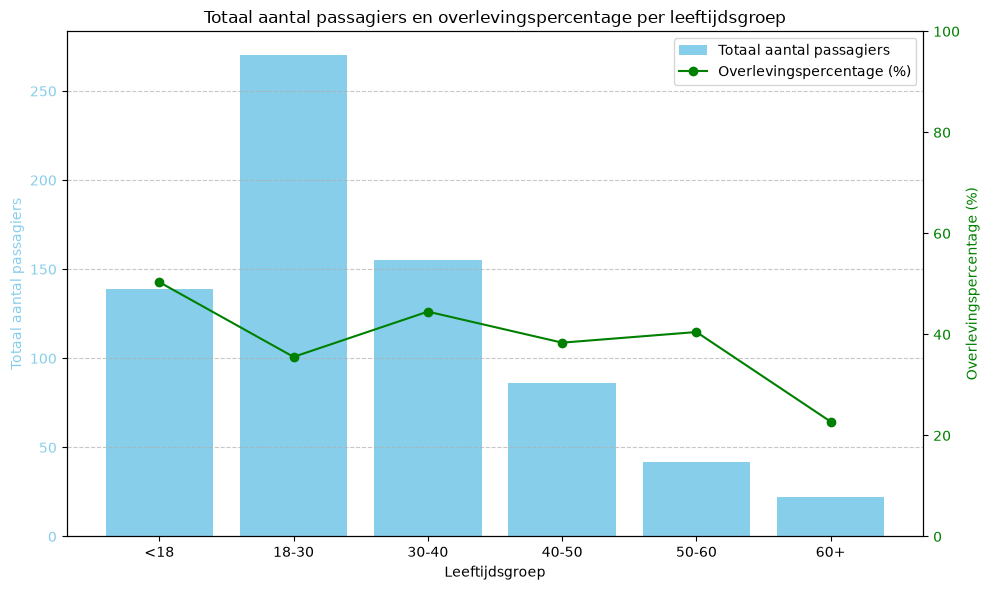

In [1]:
"""
Created on Thu Sep  7 16:04:27 2023
Aangepast: overzichtelijkere grafieken + correcte labels
 
@author: jbrweelden
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# Import data en bekijk dataframe
df = pd.read_csv('Titanic.csv')
print(df)
 
##### Data-check vooraf #####
# De Titanic-dataset heeft bekend veel ontbrekende waarden in 'Age'.
# Als je dat negeert, worden die passagiers straks stilzwijgend uit de
# leeftijdsgrafiek weggelaten (groupby laat NaN-groepen standaard vallen).
missing_age = df['Age'].isna().sum()
print(f"Ontbrekende leeftijden: {missing_age} van de {len(df)} passagiers "
      f"({missing_age / len(df):.1%}) — deze vallen buiten de leeftijdsgrafiek hieronder.")
 
 
##### Grafiek 1: overlevenden vs. overledenen per geslacht #####
 
# Bereken totaal, aantal overlevenden EN aantal overledenen per geslacht.
# (In de oude code werd 'count' met het label "Died" getekend, terwijl
# 'count' het TOTAAL aantal passagiers is, niet het aantal overledenen.)
sex_counts = df.groupby('Sex')['Survived'].agg(total='count', survived='sum')
sex_counts['died'] = sex_counts['total'] - sex_counts['survived']
 
x = np.arange(len(sex_counts.index))  # positie per geslacht op de x-as
width = 0.35  # breedte van elke losse staaf
 
fig, ax = plt.subplots(figsize=(8, 6))
 
# Twee staven NAAST elkaar per geslacht, in plaats van twee staven
# OP elkaar (wat in de oude versie de verwarring veroorzaakte).
bars_survived = ax.bar(x - width / 2, sex_counts['survived'], width, label='Overleefd')
bars_died = ax.bar(x + width / 2, sex_counts['died'], width, label='Overleden')
 
# Aantallen boven de staven zetten maakt vergelijken makkelijker
ax.bar_label(bars_survived, padding=3)
ax.bar_label(bars_died, padding=3)
 
ax.set_xticks(x)
ax.set_xticklabels(sex_counts.index)
ax.set_xlabel('Geslacht')
ax.set_ylabel('Aantal passagiers')
ax.set_title('Aantal overlevenden en overledenen per geslacht')
ax.legend()
 
plt.tight_layout()
plt.show()
 
 
##### Grafiek 2: overlevingspercentage per leeftijdsgroep #####
 
# Leeftijdsgroepen definiëren
age_bins = [0, 18, 30, 40, 50, 60, 100]
age_labels = ['<18', '18-30', '30-40', '40-50', '50-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
 
# observed=True voorkomt een FutureWarning bij groeperen op een categorie-kolom
age_group_data = df.groupby('AgeGroup', observed=True)['Survived'].agg(total='count', survived='sum')
age_group_data['SurvivalRate'] = age_group_data['survived'] / age_group_data['total'] * 100
 
fig, ax1 = plt.subplots(figsize=(10, 6))
 
bars = ax1.bar(age_group_data.index, age_group_data['total'], color='skyblue',
                label='Totaal aantal passagiers')
ax1.set_xlabel('Leeftijdsgroep')
ax1.set_ylabel('Totaal aantal passagiers', color='skyblue')
ax1.set_title('Totaal aantal passagiers en overlevingspercentage per leeftijdsgroep')
ax1.tick_params(axis='y', labelcolor='skyblue')
 
ax2 = ax1.twinx()
line = ax2.plot(age_group_data.index, age_group_data['SurvivalRate'], marker='o',
                 color='green', label='Overlevingspercentage (%)')
ax2.set_ylabel('Overlevingspercentage (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim(0, 100)  # vast bereik van 0-100% maakt percentages makkelijker te lezen
 
# Handles van BEIDE assen samenvoegen voor één complete legenda.
# (In de oude code pakte plt.legend() alleen de laatst actieve as (ax2),
# waardoor "Totaal aantal passagiers" niet in de legenda stond.)
handles = [bars] + line
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper right')
 
ax1.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()